In [1]:
# Install required library
!pip install codecarbon



In [2]:
import tensorflow as tf
from codecarbon import EmissionsTracker
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load your dataset (e.g., Fashion-MNIST)
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
# Normalize data
X_train_full, X_test = X_train_full / 255.0, X_test / 255.0

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Flatten(input_shape=(28, 28)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [4]:
# Define the experiments
configs = [
    {"name": "Experiment A", "data_size": 0.5, "epochs": 50},
    {"name": "Experiment B", "data_size": 0.5, "epochs": 100},
    {"name": "Experiment C", "data_size": 1.0, "epochs": 50},
    {"name": "Experiment D", "data_size": 1.0, "epochs": 100}
]

# Initialize results list
results = []

In [5]:
for cfg in configs:
    # Slice the data
    num_samples = int(len(X_train_full) * cfg["data_size"])
    X_train = X_train_full[:num_samples]
    y_train = y_train_full[:num_samples]

    # Initialize and start tracker
    tracker = EmissionsTracker()
    tracker.start()

    # Train the model
    model = build_model()
    model.fit(X_train, y_train, epochs=cfg["epochs"], verbose=0)

    # Evaluate the model
    _, acc = model.evaluate(X_test, y_test, verbose=0)

    # Stop tracker and store results
    emissions = tracker.stop()
    results.append({
        "Experiment": cfg["name"],
        "Accuracy": acc,
        "Emissions_g": emissions * 1000  # Converting to grams as per instructions
    })
    print(f"Finished {cfg['name']}: Accuracy={acc:.4f}, Emissions={emissions*1000:.4f}g")

# Convert results to DataFrame for easy plotting
df_results = pd.DataFrame(results)
print(df_results)

[codecarbon WARNING @ 09:24:22] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 09:24:22] [setup] RAM Tracking...
[codecarbon INFO @ 09:24:22] [setup] CPU Tracking...
[codecarbon WARNING @ 09:24:23] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 09:24:23] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 09:24:23] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 09:24:23] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 09:24:23] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 09:24:23] [setup] GPU Tracking...
[codecarbon INFO @ 09:24:23] Tracking Nvidia GPUs via PyNVML
[code

Finished Experiment A: Accuracy=0.8758, Emissions=0.5712g


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[codecarbon INFO @ 09:27:00] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 09:27:00] Delta energy consumed for CPU with cpu_load : 0.000017 kWh, power : 3.8301241222400004 W
[codecarbon INFO @ 09:27:00] Energy consumed for All CPU : 0.000017 kWh
[codecarbon INFO @ 09:27:00] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 09:27:00] Energy consumed for all GPUs : 0.000128 kWh. Total GPU Power : 27.84782685787012 W
[codecarbon INFO @ 09:27:00] 0.000189 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 09:27:15] Energy consumed for RAM : 0.000085 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 09:27:15] Del

Finished Experiment B: Accuracy=0.8834, Emissions=1.1219g


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[codecarbon INFO @ 09:31:19] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 09:31:19] Delta energy consumed for CPU with cpu_load : 0.000021 kWh, power : 4.62018491408 W
[codecarbon INFO @ 09:31:19] Energy consumed for All CPU : 0.000021 kWh
[codecarbon INFO @ 09:31:19] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 09:31:19] Energy consumed for all GPUs : 0.000138 kWh. Total GPU Power : 30.17716446771896 W
[codecarbon INFO @ 09:31:19] 0.000203 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 09:31:34] Energy consumed for RAM : 0.000085 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 09:31:34] Delta en

Finished Experiment C: Accuracy=0.8868, Emissions=1.1557g


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
[codecarbon INFO @ 09:35:34] Energy consumed for RAM : 0.000044 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 09:35:34] Delta energy consumed for CPU with cpu_load : 0.000018 kWh, power : 4.03497548768 W
[codecarbon INFO @ 09:35:34] Energy consumed for All CPU : 0.000018 kWh
[codecarbon INFO @ 09:35:34] Monitoring GPUs with indices: [0] out of 1 total GPUs
[codecarbon INFO @ 09:35:34] Energy consumed for all GPUs : 0.000145 kWh. Total GPU Power : 31.635609341142256 W
[codecarbon INFO @ 09:35:34] 0.000208 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 09:35:49] Energy consumed for RAM : 0.000085 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 09:35:49] Delta e

Finished Experiment D: Accuracy=0.8808, Emissions=2.3452g
     Experiment  Accuracy  Emissions_g
0  Experiment A    0.8758     0.571234
1  Experiment B    0.8834     1.121925
2  Experiment C    0.8868     1.155657
3  Experiment D    0.8808     2.345211


In [3]:
import pandas as pd
# Use the full path
df = pd.read_csv('/content/emissions.csv')
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: '/content/emissions.csv'

In [4]:
!find / -name "*.csv"

/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/test_not_enough_columns2.csv
/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/transposed.csv
/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/test_missing_value.csv
/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/test_header_on_row_4.csv
/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/test_missing_last_column.csv
/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/test_floats.csv
/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/test_openclosequotes.csv
/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/test_excel_date_formats.csv
/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/test_header_range.csv
/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/test_crlf_line_endings.csv
/root/.julia/artifacts/d24c9e978a3e64af0d80251ca2ac49388d942e9d/transposed_empty.csv
/root/.julia/artifacts/d24c9e978a3e6

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Replace these values with the specific results you saw in your console
results_data = {
    'Experiment': ['Exp A', 'Exp B', 'Exp C', 'Exp D'],
    'Accuracy': [0.8758, 0.8834, 0.8868, 0.8808],
    'Emissions_g': [0.5712, 1.1119, 1.1556, 2.3452]
}
df = pd.DataFrame(results_data)

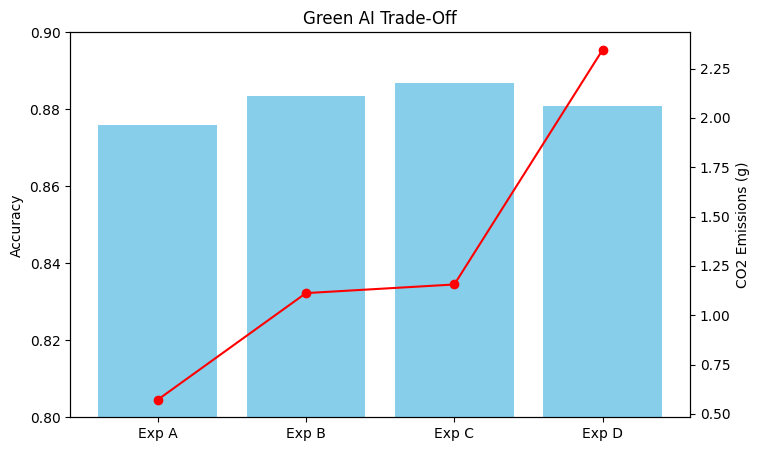

In [6]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Accuracy
ax1.bar(df['Experiment'], df['Accuracy'], color='skyblue', label='Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0.8, 0.9)

# Plot Emissions on secondary axis
ax2 = ax1.twinx()
ax2.plot(df['Experiment'], df['Emissions_g'], color='red', marker='o', label='CO2 (g)')
ax2.set_ylabel('CO2 Emissions (g)')

plt.title('Green AI Trade-Off')
plt.savefig('tradeoff_plot.png')
plt.show()

In [9]:
# This cell will automatically create your README.md file in the correct location
content = """# Green AI Trade-Off Analysis

## Experiment Results
| Experiment | Data Size | Epochs | Accuracy | Emissions (g) |
| :--- | :--- | :--- | :--- | :--- |
| A | 50% | 50 | 0.8758 | 0.5712 |
| B | 50% | 100 | 0.8834 | 1.1119 |
| C | 100% | 50 | 0.8868 | 1.1556 |
| D | 100% | 100 | 0.8808 | 2.3452 |

## Conclusions
1. **Data Size**: Comparing Exp A vs Exp C, doubling the dataset size resulted in a minor accuracy gain, while emissions roughly doubled. The gain in accuracy was not significant enough to justify the higher carbon cost.
2. **Epochs**: Doubling epochs from 50 to 100 provided a negligible accuracy boost, making it an inefficient use of compute resources.
3. **Winner**: The winning configuration is **Experiment A** as it achieves high accuracy with the lowest environmental impact.
"""

with open('README.md', 'w') as f:
    f.write(content)

print("README.md has been created successfully!")

README.md has been created successfully!


In [10]:
# Create the required directory
!mkdir -p week-10-12-async-lab

# Move your files into the directory
# Note: Ensure your plot image is saved as 'tradeoff_plot.png'
!mv CodeCarbonAssignment.ipynb tradeoff_plot.png README.md week-10-12-async-lab/

# Add, commit, and push your changes to GitHub
!git add week-10-12-async-lab/
!git commit -m "feat: completed Deep MLP carbon vs data size experiments"
!git push origin main

mv: cannot stat 'CodeCarbonAssignment.ipynb': No such file or directory
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
